# Computational Thinking

## The Essence of Computational Thinking


Computational thinking is a fundamental methodology for solving problems by reformulating them in ways that enable systematic, step-by-step execution [@wing2006computational; @weintrop2016defining]. Rather than a programming technique, it represents a way of approaching problems in the computational age. The methodology rests on four interconnected practices: breaking problems into smaller subproblems (decomposition), representing physical systems as mathematical models (abstraction), expressing solutions as iterative procedures (algorithmic thinking), and exploring system behavior through step-by-step simulations (modeling and simulation). When analyzing a damped pendulum, we decompose the motion into force calculations and state updates at each time step, abstract the physical system as ordinary differential equations, design an algorithm that repeatedly computes and updates the system state, and run simulations to generate trajectories that reveal the pendulum's behavior over time.


### A Fundamental Shift, Not a Shortcut


This approach is not a shortcut but a fundamental shift in problem-solving methodology. Consider a pendulum swinging with air resistance at large angles: the governing nonlinear differential equation admits no closed-form solution in elementary functions. Traditional analytical methods reach an impasse, but computational thinking circumvents this entirely by treating the system as something to be simulated rather than solved symbolically [@burden2015numerical]. The principle is simple: humans excel at modeling physical situations and interpreting results, while computers excel at rapid, tireless calculation. By delegating mechanical computation to machines, we tackle problems of complexity far beyond purely analytical methods.


### Computational Thinking in Engineering: The Iterative Approach



In engineering and applied mathematics, computational thinking transforms continuous physical processes into discrete, iterative steps. This iterative process constitutes the algorithm that solves the problem.



A continuous process, such as the motion of an object over time, is decomposed into a sequence of small time steps $\Delta t$. We recognize that the same physical laws apply at every step: the state at time $(t + \Delta t)$ is determined by the state at time $t$. This repeating pattern enables an algorithmic solution through a loop that calculates state changes and updates the system until a desired condition is met. The system is encoded as update rules on state variables, and these rules execute repeatedly to generate a numerical trajectory for analysis and visualization.


### An Engineering Example: A Pendulum with Air Resistance



A damped pendulum illustrates both the limitations of analytical methods and the strength of computational thinking. The governing differential equation $mL\ddot{\theta} + cL\dot{\theta} + mg\sin(\theta) = 0$ is nonlinear due to the $\sin(\theta)$ term, preventing closed-form solution for large angles. The computational approach bypasses this impasse by discretizing time into small steps $\Delta t$ and treating angular acceleration as approximately constant over each step. At each time step, we calculate the angular acceleration $\alpha = -(c/m)\dot{\theta} - (g/L)\sin(\theta)$ from the current state, update the angular velocity $\omega_{\text{new}} = \omega + \alpha \Delta t$, and update the angle $\theta_{\text{new}} = \theta + \omega_{\text{new}} \Delta t$. This iterative process generates a numerical trajectory that would otherwise be unobtainable, demonstrating how computational thinking provides solutions when traditional analytical techniques fail.



### Intuition and Modularity: The Brake Pad Example



Beyond tackling analytically difficult problems, the computational approach often proves more intuitive. Consider calculating a car's stopping distance when the brake pad friction coefficient $\mu$ decreases with temperature. An analytical solution requires solving coupled integral-differential equations describing the feedback between energy dissipation, temperature, and braking force. The computational approach simply simulates cause and effect: at each time step, look up $\mu$ from the current temperature, compute the braking force $F = \mu F_{\text{normal}}$, calculate deceleration and distance traveled, convert work to heat, and update the temperature. Each line of code mirrors a physical process, making the model transparent and easily modified.


### Applying Computational Thinking: A Practical Workflow



Computational thinking becomes a repeatable workflow structured as **Formulate–Solve–Analyze**. In the formulation phase, we translate real-world problems into mathematical and computational models by defining variables, coordinates, and governing principles. The solution phase delegates mechanical calculation to appropriate tools: symbolic algebra systems, numerical libraries, or custom time-stepping schemes. The analysis phase returns to human judgment: we visualize results through plots and animations, validate solutions by checking units and limiting cases, and interpret what the results reveal about system behavior. This workflow transforms computational thinking from an abstract concept into practical methodology.


## Example 1 - boat navigation

Let the coordinates be in km. A boat is at point (-40, -20) and is headed toward the point (50, 80) with a speed of 10 km/h. Compute the point where the boat needs to make a $60^\circ$ turn to continue in a straight line towards the harbor at the point (40, 50). How long will it take the boat to reach the harbor?

### Formulation



We can solve this problem geometrically. Let the starting point be $P_1 = (-40, -20)$, the initial heading point be $P_2 = (50, 80)$, the harbor be $P_H = (40, 50)$, and the unknown turning point be $P_T = (x_t, y_t)$.


It's always a good idea to sketch the situation to visualize the problem.

In [24]:
#| echo: false
import matplotlib.pyplot as plt
import numpy as np


%config InlineBackend.figure_format = 'svg'

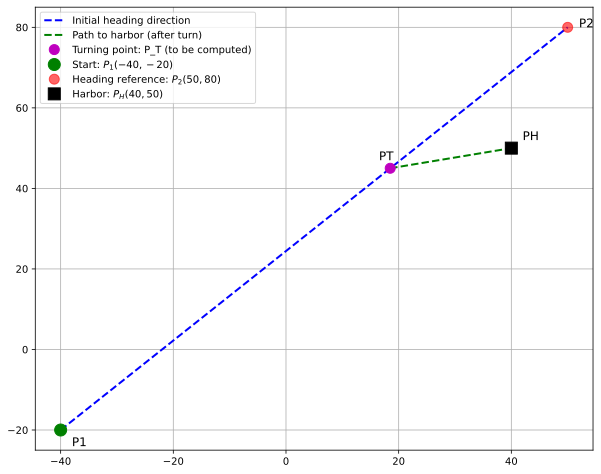

In [25]:
#| code-fold: true
#| classes: size-80
P1 = np.array([-40, -20])  # Starting point
P2 = np.array([50, 80])     # Initial heading point
P_harbor = np.array([40, 50])  # Harbor (destination)

fig, ax = plt.subplots(figsize=(10, 8))
ax.grid(True)

dir_vector = P2 - P1
ax.plot(*zip(*[P1, P1 + dir_vector]),
        'b--', linewidth=2, label='Initial heading direction')

P_turn_approx = P1 + dir_vector * 0.65

ax.plot([P_turn_approx[0], P_harbor[0]],
        [P_turn_approx[1], P_harbor[1]],
        'g--', linewidth=2, label='Path to harbor (after turn)')

ax.plot(P_turn_approx[0], P_turn_approx[1], 'mo', markersize=10, 
        label='Turning point: P_T (to be computed)')

ax.plot(P1[0], P1[1], 'go', markersize=12, label='Start: $P_1(-40, -20)$')
ax.plot(P2[0], P2[1], 'ro', markersize=10, alpha=0.6, label='Heading reference: $P_2(50, 80)$')
ax.plot(P_harbor[0], P_harbor[1], 'ks', markersize=12, label='Harbor: $P_H(40, 50)$')

ax.text(P1[0]+2, P1[1]-4, 'P1', fontsize=12)
ax.text(P2[0]+2, P2[1], 'P2', fontsize=12)
ax.text(P_harbor[0]+2, P_harbor[1]+2, 'PH', fontsize=12)
ax.text(P_turn_approx[0]-2, P_turn_approx[1]+2, 'PT', fontsize=12)
ax.legend()


Here, we have drawn the known points and the trajectory of the boat. The unknown turning point $P_T$ lies somewhere on the line segment between $P_1$ and $P_2$. We have modeled this turning point as 65% of the way from $P_1$ to $P_2$ just for illustration; the actual turning point will be computed below.

65% of the way from $P_1$ to $P_2$ is the same as starting at $P_1$ and going 65% of the way along the vector $P_2 - P_1$. We start simple: Let's parameterize the turning point using the parameter $t$ such that 

$$
P_T = P_1 + t(P_2 - P_1)
$$


But we also need to fulfill the $60^\circ$ turn condition. Let $\boldsymbol v_{1} = P_T - P_1$ and $\boldsymbol v_{2} = P_H - P_T$. The angle between the vectors $\boldsymbol v_{1}$ and $\boldsymbol v_{2}$ must be $60^\circ$. Using the dot product formula, we have:

$$
\boldsymbol{v_1} \cdot \boldsymbol{v_2} = \|\boldsymbol{v_1}\| \|\boldsymbol{v_2}\| \cos(60^\circ)
$$

Once we solve for $t$, we can compute the turning point $P_T$. Finally, we can compute the total distance from $P_1$ to $P_T$ to $P_H$ and divide by the speed to get the time taken. We can delegate the algebraic manipulation to SymPy.

::: {.callout-note}
This formulation phase is crucial! It is often the hard part and where students get lost in computation. Do not start computing too early! Formulate a strategy first! Start with a sketch if applicable. Explicitly write down what you know and what you need to find. Identify the variables and parameters. Then formulate a plan to connect the knowns to the unknowns. Find equations that relate the variables. Only then start computing, starting with intial algebraic expansions using sympy. To grasp the problem, identifying unknowns and knowns, and writing down the equations is often more important than the final numerical answer. Do not rush into coding!

Always try to keep things symbolic as long as possible. Numerical values can be plugged in at the end.
:::

In [26]:
import sympy as sp

from mechanicskit import display_labeled_latex

In [27]:
#| code-fold: false
t = sp.symbols('t', real=True)

P1 = sp.Matrix([-40, -20])
P2 = sp.Matrix([50, 80])
P_harbor = sp.Matrix([40, 50])
dir_vector = P2 - P1
P_T = P1 + t * dir_vector

In [28]:
#| echo: false
display_labeled_latex(r"\boldsymbol P_T=", P_T)

<IPython.core.display.Latex object>

In [29]:
#| code-fold: false
v_1 = P2 - P1
v_2 = P_harbor - P_T

eq = sp.Eq(v_1.dot(v_2), v_1.norm() * v_2.norm() * sp.cos(60 * sp.pi / 180))
eq

Eq(14200 - 18100*t, 5*sqrt(181)*sqrt((90*t - 80)**2 + (100*t - 70)**2))

In [30]:
#| code-fold: false
sol = sp.solve(eq, t)
t_turn = sol[0]
t_turn.evalf()

0.730304118363405

In [31]:
#| code-fold: false
P_turn = P1 + t_turn * dir_vector
P_turn.evalf()

Matrix([
[25.7273706527065],
[53.0304118363405]])

In [32]:
#| code-fold: false
v = 10 # km/h
t_to_turn = (v_1.norm() / v).evalf() # hours to reach turning point
t_to_harbor = (v_2.norm() / v).subs(t,t_turn).evalf() # hours from turning point to harbor
t_total = t_to_turn + t_to_harbor

print(f"Time to turn: {t_to_turn:.2f} hours")
print(f"Time to harbor after turn: {t_to_harbor:.2f} hours")
print(f"Total time: {t_total:.2f} hours")

Time to turn: 13.45 hours
Time to harbor after turn: 1.46 hours
Total time: 14.91 hours


### Verification

Finally, we plot the trajectory to visually verify that our solution is correct. The plot should show the boat starting at $P_1$, heading towards $P_2$, making a turn at the calculated point $P_T$, and then proceeding to the harbor $P_H$. This confirms that our mathematical model and its solution accurately reflect the physical reality described in the problem.

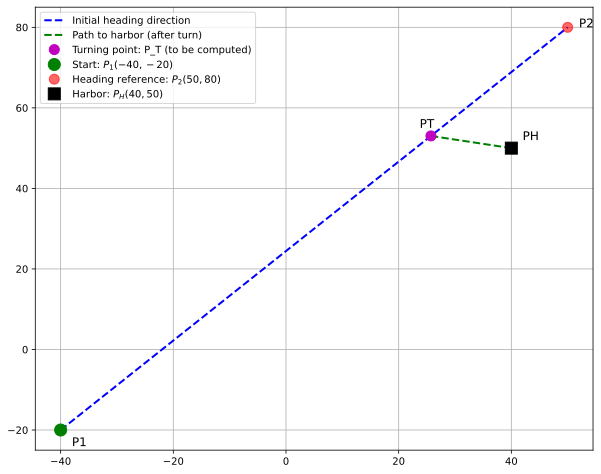

In [33]:
#| code-fold: true
#| classes: size-80
P1 = np.array([-40, -20])  # Starting point
P2 = np.array([50, 80])     # Initial heading point
P_harbor = np.array([40, 50])  # Harbor (destination)

fig, ax = plt.subplots(figsize=(10, 8))
ax.grid(True)

dir_vector = P2 - P1
ax.plot(*zip(*[P1, P1 + dir_vector]),
        'b--', linewidth=2, label='Initial heading direction')

P_turn_exact = P_turn.evalf()

ax.plot([P_turn_exact[0], P_harbor[0]],
        [P_turn_exact[1], P_harbor[1]],
        'g--', linewidth=2, label='Path to harbor (after turn)')

ax.plot(P_turn_exact[0], P_turn_exact[1], 'mo', markersize=10, 
        label='Turning point: P_T (to be computed)')

ax.plot(P1[0], P1[1], 'go', markersize=12, label='Start: $P_1(-40, -20)$')
ax.plot(P2[0], P2[1], 'ro', markersize=10, alpha=0.6, label='Heading reference: $P_2(50, 80)$')
ax.plot(P_harbor[0], P_harbor[1], 'ks', markersize=12, label='Harbor: $P_H(40, 50)$')

ax.text(P1[0]+2, P1[1]-4, 'P1', fontsize=12)
ax.text(P2[0]+2, P2[1], 'P2', fontsize=12)
ax.text(P_harbor[0]+2, P_harbor[1]+2, 'PH', fontsize=12)
ax.text(P_turn_exact[0]-2, P_turn_exact[1]+2, 'PT', fontsize=12)
ax.legend()


## Example 2 - boat navigation with a current

Lets revisit example 1, but now assume that there is a current flowing in the positive x-direction at 5 km/h. Compute the point where the boat needs to make a $60^\circ$ turn to continue in a straight line towards the harbor at the point (40, 50). How long will it take the boat to reach the harbor?


### Formulation

The presence of a current complicates the problem by introducing a difference between the boat's velocity relative to the water and its velocity relative to the ground. The boat's speed of 10 km/h is relative to the water, but its actual path (ground track) is the vector sum of its own velocity and the current's velocity. Let's denote these as $\boldsymbol{v}_{boat}$, $\boldsymbol{v}_{current}$, and $\boldsymbol{v}_{ground} = \boldsymbol{v}_{boat} + \boldsymbol{v}_{current}$.

**Leg 1:** The boat *steers* towards $P_2$, so the direction of $\boldsymbol{v}_{boat,1}$ is known. Its magnitude is the boat's speed. We can thus find $\boldsymbol{v}_{ground,1}$. The first part of the trajectory is a straight line in the direction of $\boldsymbol{v}_{ground,1}$. The turning point $P_T$ is a function of the time traveled, $t_1$: $P_T = P_1 + t_1 \boldsymbol{v}_{ground,1}$.

**Leg 2:** After the turn, the boat must travel from $P_T$ to $P_H$. The direction of the ground track, $\boldsymbol{v}_{ground,2}$, is thus known. The magnitude of the boat's velocity is still 10 km/h: $\|\boldsymbol{v}_{boat,2}\| = 10$. Using the vector sum $\boldsymbol{v}_{boat,2} = \boldsymbol{v}_{ground,2} - \boldsymbol{v}_{current}$, we can establish a relationship that allows us to solve for the ground speed on the second leg, $\|\boldsymbol{v}_{ground,2}\|$.

**Turn Condition:** The $60^\circ$ turn applies to the boat's *ground track*. This means the angle between the ground velocity vectors $\boldsymbol{v}_{ground,1}$ and $\boldsymbol{v}_{ground,2}$ is $120^\circ$. This provides the final equation we need to solve for the unknown time $t_1$.

### Verification

We again plot the results. This time, we plot the boat's actual path over the ground. We also show the directions the boat is *steering* as dashed lines. The difference between the steering direction and the ground track visually represents the effect of the current, often called the 'crab angle'.

## Example 3 - boat navigation with a bad navigation system

In this situation the boat is unaware of the current flowing in the positive x-direction at 5 km/h. The boat is at point (-40, -20) and is headed toward the point (50, 80) with a speed of 10 km/h. Assume the boat takes the $60^\circ$ turn at the same coordinates as in example 1. After turning the captain realizes that the boat is drifting off course. Every kilometer they correct their coarse by steering towards the harbor at (40, 50). How long will it take the boat to reach the harbor now? Plot the trajectory of the boat.